In [25]:
from pathlib import Path

# 현재 실행 위치 확인
cwd = Path.cwd()

# 노트북 실행 위치가 notebooks일 수도 있고, 프로젝트 루트일 수도 있어서 둘 다 대응
if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

TRAIN_DIR = PROJECT_ROOT / "train"
VAL_DIR = PROJECT_ROOT / "validation"

TRAIN_IMG_DIR = TRAIN_DIR / "images"
TRAIN_ANN_DIR = TRAIN_DIR / "annotations"

VAL_IMG_DIR = VAL_DIR / "images"
VAL_ANN_DIR = VAL_DIR / "annotations"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
RESULT_DIR = OUTPUT_DIR / "results"

print("현재 실행 위치:", cwd)
print("프로젝트 루트:", PROJECT_ROOT)
print("train images 존재:", TRAIN_IMG_DIR.exists())
print("train annotations 존재:", TRAIN_ANN_DIR.exists())
print("validation images 존재:", VAL_IMG_DIR.exists())
print("validation annotations 존재:", VAL_ANN_DIR.exists())

현재 실행 위치: c:\NEU-DET\notebooks
프로젝트 루트: c:\NEU-DET
train images 존재: True
train annotations 존재: True
validation images 존재: True
validation annotations 존재: True


In [26]:
train_images = list(TRAIN_IMG_DIR.rglob("*.jpg"))
val_images = list(VAL_IMG_DIR.rglob("*.jpg"))

train_xmls = list(TRAIN_ANN_DIR.glob("*.xml"))
val_xmls = list(VAL_ANN_DIR.glob("*.xml"))

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Train annotations:", len(train_xmls))
print("Validation annotations:", len(val_xmls))
print("Total images:", len(train_images) + len(val_images))
print("Total annotations:", len(train_xmls) + len(val_xmls))

Train images: 1440
Validation images: 360
Train annotations: 1440
Validation annotations: 360
Total images: 1800
Total annotations: 1800


In [27]:
import pandas as pd

class_counts = []

for split_name, img_dir in [("train", TRAIN_IMG_DIR), ("validation", VAL_IMG_DIR)]:
    for class_dir in sorted(img_dir.iterdir()):
        if class_dir.is_dir():
            count = len(list(class_dir.glob("*.jpg")))
            class_counts.append({
                "split": split_name,
                "class": class_dir.name,
                "image_count": count
            })

df_class_counts = pd.DataFrame(class_counts)
df_class_counts

,split,class,image_count
0,train,crazing,240
1,train,inclusion,240
2,train,patches,240
3,train,pitted_surface,240
4,train,rolled-in_scale,240
5,train,scratches,240
6,validation,crazing,60
7,validation,inclusion,60
8,validation,patches,60
9,validation,pitted_surface,60


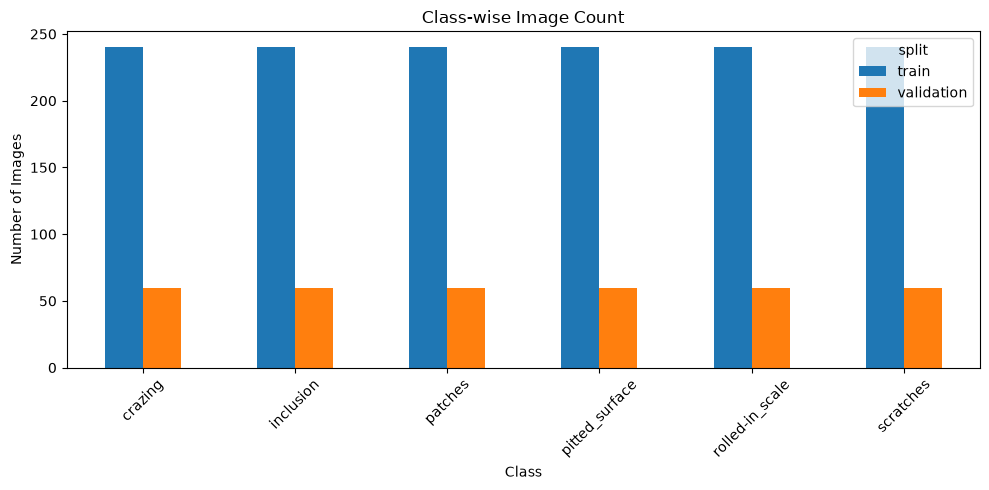

저장 위치: c:\NEU-DET\outputs\figures\class_image_count.png


In [28]:
import matplotlib.pyplot as plt

pivot_counts = df_class_counts.pivot(
    index="class",
    columns="split",
    values="image_count"
)

ax = pivot_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Class-wise Image Count")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()

save_path = FIGURE_DIR / "class_image_count.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("저장 위치:", save_path)

In [29]:
train_image_stems = {p.stem for p in train_images}
val_image_stems = {p.stem for p in val_images}

train_xml_stems = {p.stem for p in train_xmls}
val_xml_stems = {p.stem for p in val_xmls}

print("[Train]")
print("이미지는 있는데 XML이 없는 파일:", sorted(train_image_stems - train_xml_stems))
print("XML은 있는데 이미지가 없는 파일:", sorted(train_xml_stems - train_image_stems))

print("\n[Validation]")
print("이미지는 있는데 XML이 없는 파일:", sorted(val_image_stems - val_xml_stems))
print("XML은 있는데 이미지가 없는 파일:", sorted(val_xml_stems - val_image_stems))

[Train]
이미지는 있는데 XML이 없는 파일: []
XML은 있는데 이미지가 없는 파일: []

[Validation]
이미지는 있는데 XML이 없는 파일: []
XML은 있는데 이미지가 없는 파일: []


In [30]:
import xml.etree.ElementTree as ET
import pandas as pd

def parse_annotation(xml_path, split):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text

    size = root.find("size")
    img_width = int(size.find("width").text)
    img_height = int(size.find("height").text)

    records = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        bbox = obj.find("bndbox")
        xmin = int(float(bbox.find("xmin").text))
        ymin = int(float(bbox.find("ymin").text))
        xmax = int(float(bbox.find("xmax").text))
        ymax = int(float(bbox.find("ymax").text))

        bbox_width = xmax - xmin
        bbox_height = ymax - ymin
        bbox_area = bbox_width * bbox_height
        aspect_ratio = bbox_width / bbox_height if bbox_height != 0 else None

        records.append({
            "split": split,
            "xml_file": xml_path.name,
            "filename": filename,
            "class": class_name,
            "img_width": img_width,
            "img_height": img_height,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "bbox_width": bbox_width,
            "bbox_height": bbox_height,
            "bbox_area": bbox_area,
            "aspect_ratio": aspect_ratio
        })

    return records


all_records = []

for xml_path in train_xmls:
    all_records.extend(parse_annotation(xml_path, "train"))

for xml_path in val_xmls:
    all_records.extend(parse_annotation(xml_path, "validation"))

df_bbox = pd.DataFrame(all_records)

print("총 객체 수:", len(df_bbox))
df_bbox.head()

총 객체 수: 4189


,split,xml_file,filename,class,img_width,img_height,xmin,ymin,xmax,ymax,bbox_width,bbox_height,bbox_area,aspect_ratio
0,train,crazing_1.xml,crazing_1.jpg,crazing,200,200,2,2,193,194,191,192,36672,0.994792
1,train,crazing_10.xml,crazing_10.jpg,crazing,200,200,60,20,194,69,134,49,6566,2.734694
2,train,crazing_10.xml,crazing_10.jpg,crazing,200,200,9,84,197,198,188,114,21432,1.649123
3,train,crazing_100.xml,crazing_100.jpg,crazing,200,200,1,10,108,121,107,111,11877,0.963964
4,train,crazing_100.xml,crazing_100.jpg,crazing,200,200,35,1,200,83,165,82,13530,2.012195


In [31]:
# 결과 저장 폴더 확인
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

# bbox annotation 결과 저장
bbox_csv_path = RESULT_DIR / "bbox_annotations.csv"
df_bbox.to_csv(bbox_csv_path, index=False, encoding="utf-8-sig")

print("저장 완료:", bbox_csv_path)

저장 완료: c:\NEU-DET\outputs\results\bbox_annotations.csv


In [32]:
object_counts = (
    df_bbox
    .groupby(["split", "class"])
    .size()
    .reset_index(name="object_count")
)

object_counts

,split,class,object_count
0,train,crazing,527
1,train,inclusion,852
2,train,patches,688
3,train,pitted_surface,345
4,train,rolled-in_scale,496
5,train,scratches,427
6,validation,crazing,162
7,validation,inclusion,159
8,validation,patches,193
9,validation,pitted_surface,87


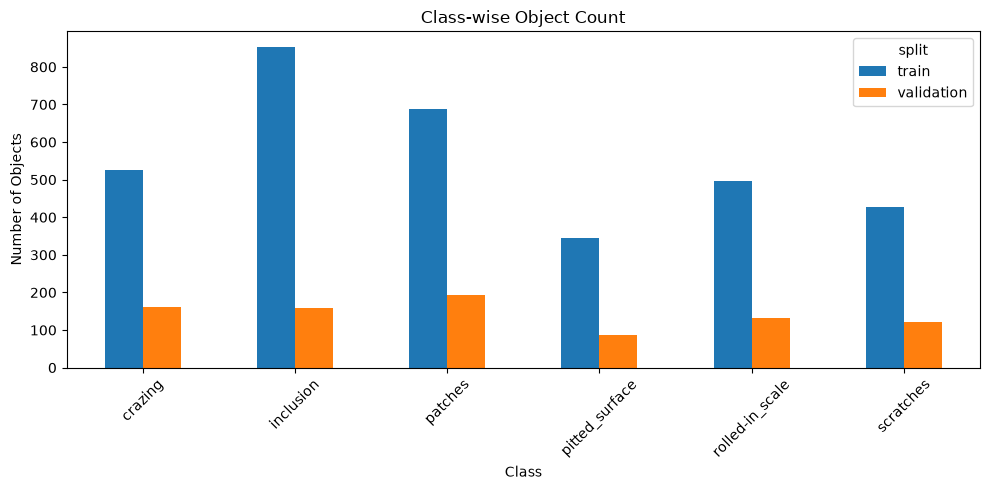

저장 위치: c:\NEU-DET\outputs\figures\class_object_count.png


In [33]:
import matplotlib.pyplot as plt

pivot_objects = object_counts.pivot(
    index="class",
    columns="split",
    values="object_count"
)

ax = pivot_objects.plot(kind="bar", figsize=(10, 5))

plt.title("Class-wise Object Count")
plt.xlabel("Class")
plt.ylabel("Number of Objects")
plt.xticks(rotation=45)
plt.tight_layout()

save_path = FIGURE_DIR / "class_object_count.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("저장 위치:", save_path)

In [34]:
bbox_stats = (
    df_bbox
    .groupby("class")[["bbox_width", "bbox_height", "bbox_area", "aspect_ratio"]]
    .describe()
)

bbox_stats

bbox_width                                                    \
                     count        mean        std   min   25%    50%     75%   
class                                                                          
crazing              689.0  125.146589  40.478393  31.0  92.0  126.0  157.00   
inclusion           1011.0   28.508408  14.590336  10.0  19.0   25.0   34.00   
patches              881.0   56.238365  20.703149  14.0  41.0   52.0   69.00   
pitted_surface       432.0  127.337963  52.913594  23.0  81.0  125.0  183.00   
rolled-in_scale      628.0   73.070064  27.998032  21.0  51.0   68.0   91.25   
scratches            548.0   61.330292  67.108458   8.0  16.0   26.5   90.50   

                       bbox_height              ... bbox_area           \
                   max       count        mean  ...       75%      max   
class                                           ...                      
crazing          199.0       689.0   75.349782  ...  11448.00  36672.0   
inclusion        138.0      1011.0   85.097923  ...   3874.00  19890.0   
patches          159.0       881.0   83.371169  ...   6901.00  26410.0   
pitted_surface   199.0       432.0  172.965278  ...  32908.25  39601.0   
rolled-in_scale  176.0       628.0   77.807325  ...   8070.00  23560.0   
scratches        199.0       548.0  114.981752  ...   5259.75  18304.0   

                aspect_ratio                                          \
                       count      mean       std       min       25%   
class                                                                  
crazing                689.0  1.886780  0.900647  0.206667  1.218391   
inclusion             1011.0  0.449496  0.414782  0.092308  0.262637   
patches                881.0  0.834163  0.468805  0.193548  0.519481   
pitted_surface         432.0  0.773785  0.376533  0.141414  0.493632   
rolled-in_scale        628.0  1.134011  0.658718  0.265306  0.656426   
scratches              548.0  2.205421  3.519251  0.045455  0.112364   

                                                
                      50%       75%        max  
class                                           
crazing          1.794872  2.434211   6.206897  
inclusion        0.367347  0.489996   5.400000  
patches          0.725806  1.000000   3.800000  
pitted_surface   0.758729  1.000000   2.875000  
rolled-in_scale  0.978302  1.405360   5.043478  
scratches        0.177705  4.541667  18.000000  

[6 rows x 32 columns]

<Figure size 1000x500 with 0 Axes>

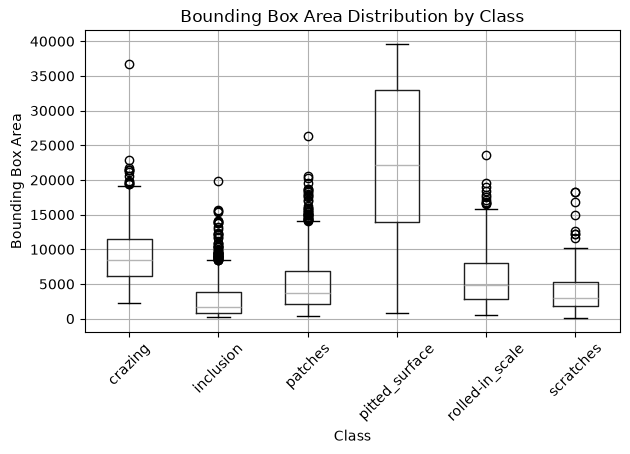

저장 위치: c:\NEU-DET\outputs\figures\bbox_area_distribution.png


In [35]:
plt.figure(figsize=(10, 5))

df_bbox.boxplot(
    column="bbox_area",
    by="class",
    rot=45
)

plt.title("Bounding Box Area Distribution by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Bounding Box Area")
plt.tight_layout()

save_path = FIGURE_DIR / "bbox_area_distribution.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("저장 위치:", save_path)

<Figure size 1000x500 with 0 Axes>

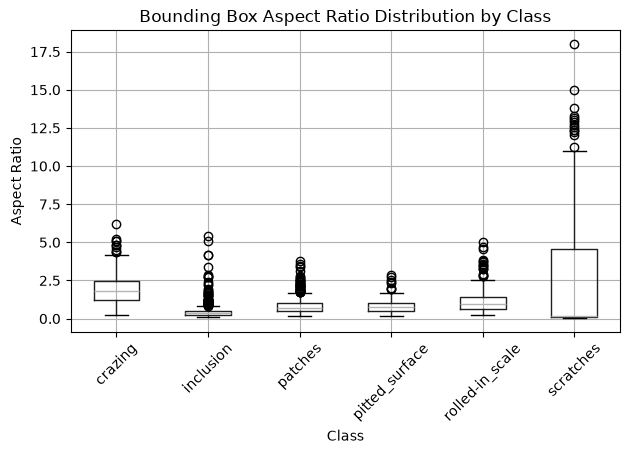

저장 위치: c:\NEU-DET\outputs\figures\bbox_aspect_ratio_distribution.png


In [36]:
plt.figure(figsize=(10, 5))

df_bbox.boxplot(
    column="aspect_ratio",
    by="class",
    rot=45
)

plt.title("Bounding Box Aspect Ratio Distribution by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Aspect Ratio")
plt.tight_layout()

save_path = FIGURE_DIR / "bbox_aspect_ratio_distribution.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("저장 위치:", save_path)